<a href="https://colab.research.google.com/github/akankshamahindru29/demo1-/blob/main/Heart%20Disease%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_merged_heart_dataset.csv to cleaned_merged_heart_dataset.csv


In [2]:
!pip install xgboost --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

In [3]:
df = pd.read_csv('cleaned_merged_heart_dataset.csv')
print("Dataset Shape:", df.shape)

Dataset Shape: (1888, 14)


In [4]:
# Define features and target
X = df.drop("target", axis=1)   # remove target column
y = df["target"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
print(df.isnull().sum())
df.head()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


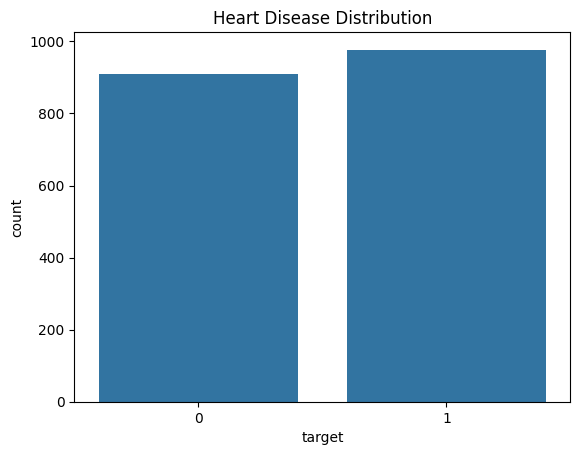

In [6]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()


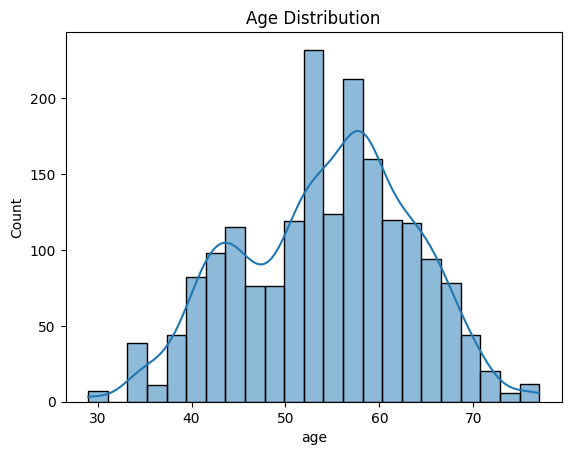

In [7]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

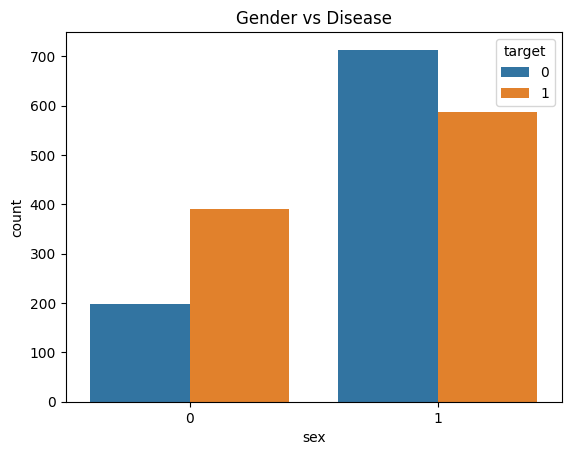

In [8]:
sns.countplot(x='sex', hue='target', data=df)
plt.title("Gender vs Disease")
plt.show()

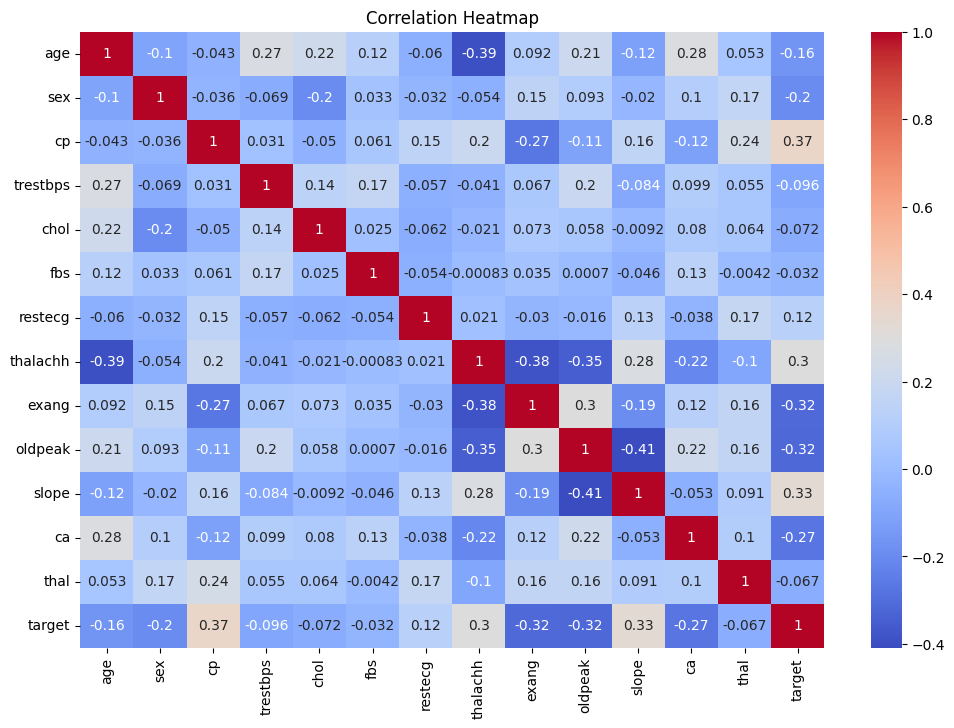

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='age', ylabel='Count'>

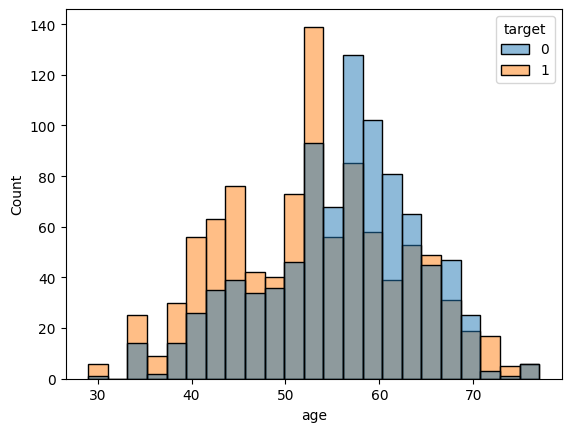

In [10]:
sns.histplot(data=df, x="age", hue="target")

In [11]:
from sklearn.model_selection import train_test_split

x = df.drop("target", axis=1)
y=df["target"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (1510, 13)
Testing Features Shape: (378, 13)
Training Labels Shape: (1510,)
Testing Labels Shape: (378,)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=9,
    min_samples_split=4,
    random_state=0
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9841269841269841


In [13]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 0.9980132450331126
Test Accuracy: 0.9841269841269841


In [14]:
from sklearn.svm import SVC
svm = SVC(C=2, kernel='rbf', probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.5661375661375662


In [15]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7275132275132276


In [16]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9788359788359788


In [17]:
from sklearn.ensemble import StackingClassifier
stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm)
    ],
    final_estimator=LogisticRegression(),
    passthrough=False
)
stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)
print("Stacking (RF + SVM → LR) Accuracy:", accuracy_score(y_test, stack_pred))

Stacking (RF + SVM → LR) Accuracy: 0.9867724867724867


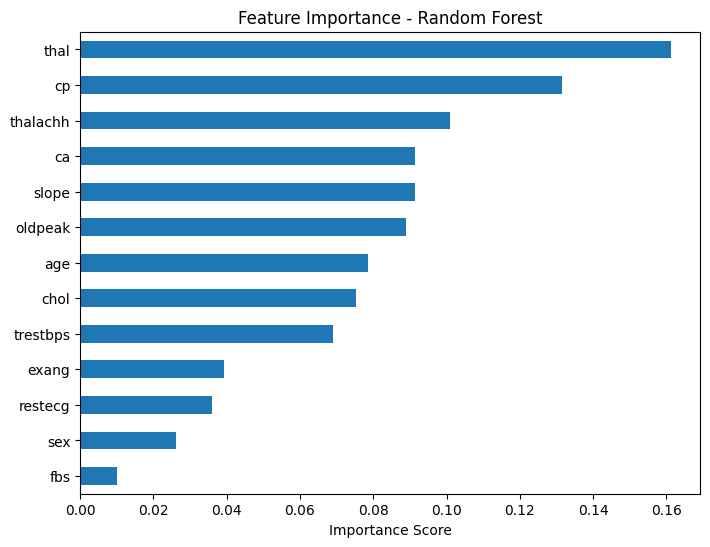

In [18]:
import pandas as pd
importance = pd.Series(rf.feature_importances_, index=X.columns)
plt.figure(figsize=(8,6))
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

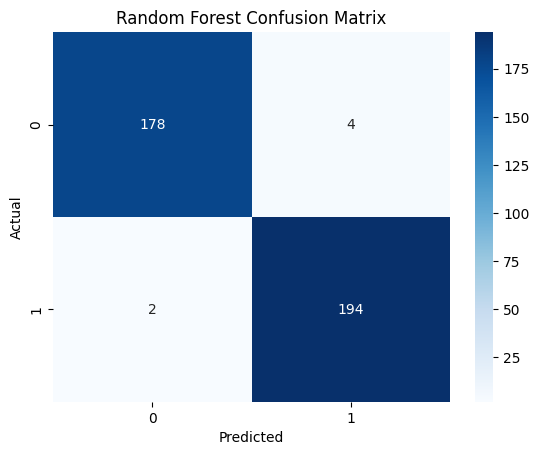

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

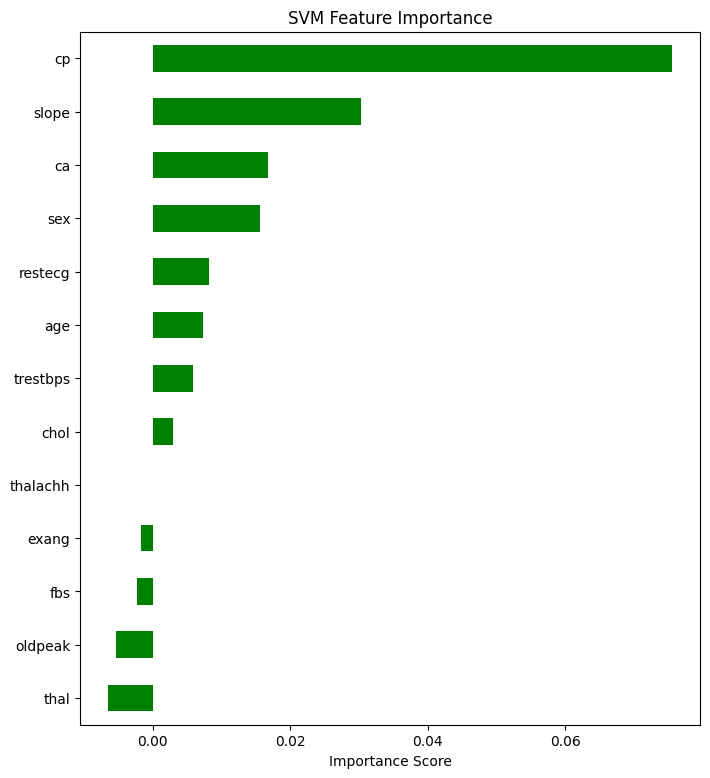

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
result = permutation_importance(svm_model, X_test, y_test, n_repeats=9, random_state=24)
importance = pd.Series(result.importances_mean, index=X.columns)
plt.figure(figsize=(8,9))
importance.sort_values().plot(kind='barh', color='green')
plt.title("SVM Feature Importance")
plt.xlabel("Importance Score")
plt.show()

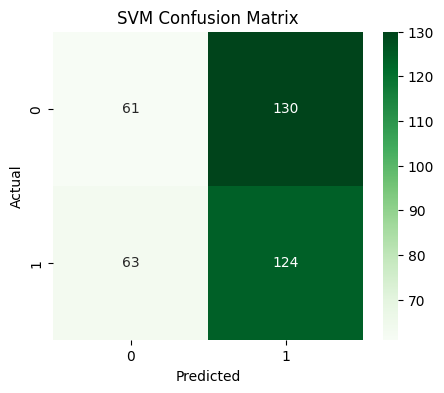

In [21]:
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

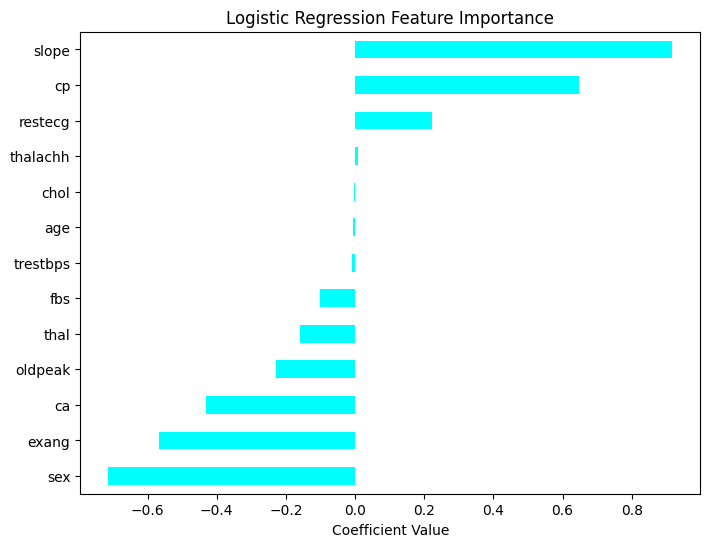

In [22]:
importance = pd.Series(lr.coef_[0], index=X.columns)
plt.figure(figsize=(8,6))
importance.sort_values().plot(kind='barh', color='cyan')
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Value")
plt.show()

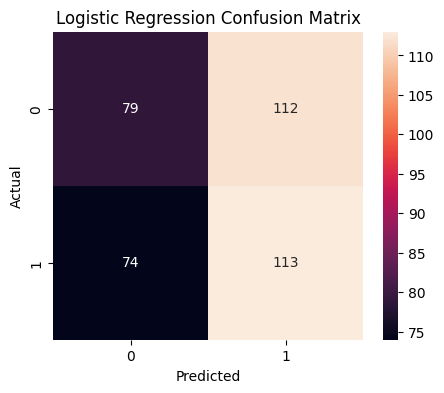

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',color='deepskyblue')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

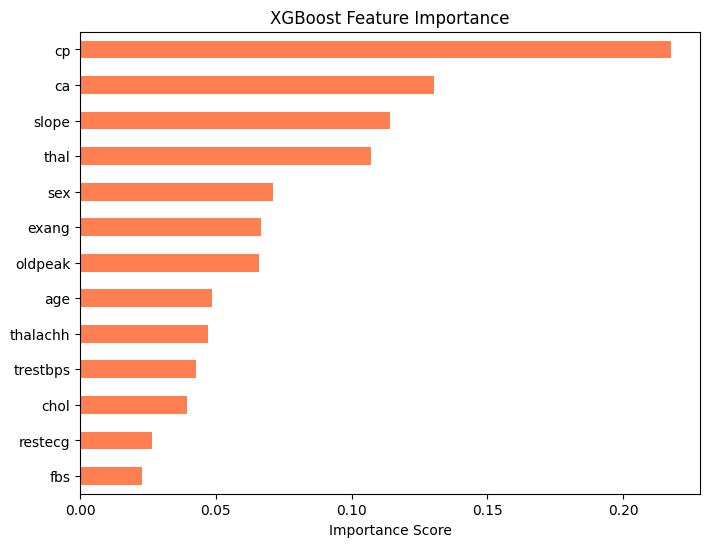

In [24]:
importance = pd.Series(xgb.feature_importances_, index=X.columns)
plt.figure(figsize=(8,6))
importance.sort_values().plot(kind='barh', color='coral')
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.show()

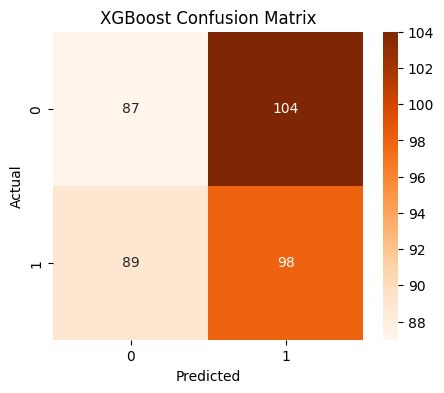

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

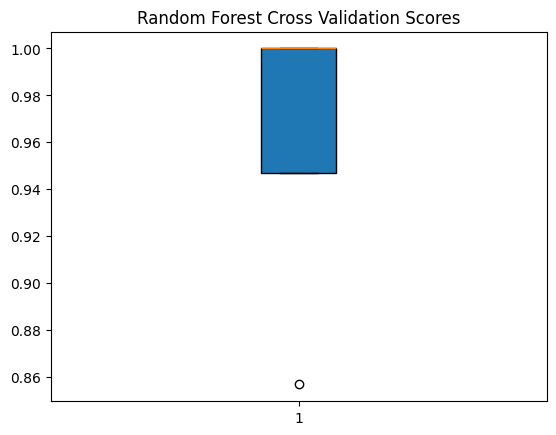

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

rf = RandomForestClassifier(random_state=42)

rf_scores = cross_val_score(rf, X, y, cv=5)

plt.figure()
plt.boxplot(rf_scores, patch_artist=True)
plt.title("Random Forest Cross Validation Scores")
plt.show()

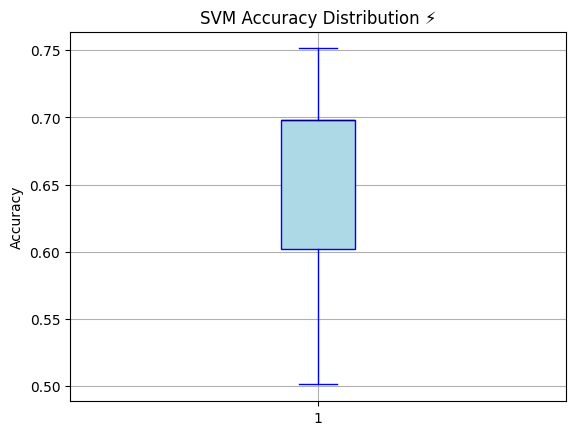

In [27]:
svm = SVC(kernel='rbf', random_state=42)
svm_scores = cross_val_score(svm, X, y, cv=5)

plt.figure()
plt.boxplot(svm_scores, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='darkblue'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'))

plt.title("SVM Accuracy Distribution ⚡")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

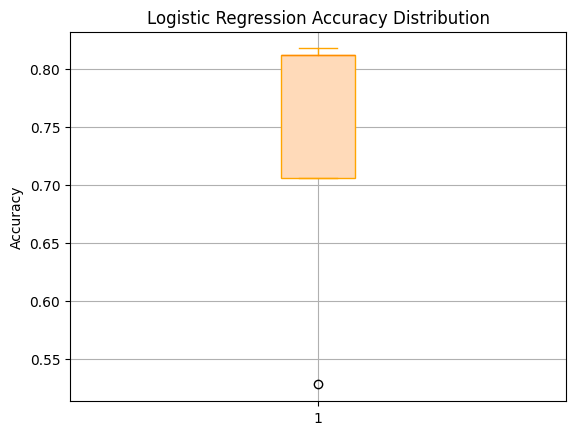

In [28]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X, y, cv=5)

plt.figure()
plt.boxplot(lr_scores, patch_artist=True,
            boxprops=dict(facecolor='peachpuff', color='orange'),
            medianprops=dict(color='darkorange'),
            whiskerprops=dict(color='orange'),
            capprops=dict(color='orange'))

plt.title("Logistic Regression Accuracy Distribution")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:23:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:23:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:23:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:23:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

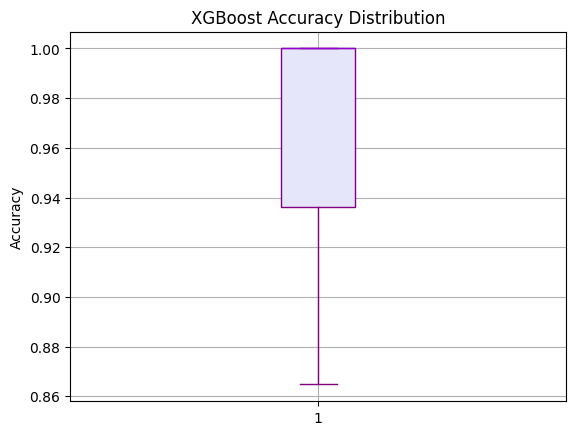

In [29]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_scores = cross_val_score(xgb, X, y, cv=5)

plt.figure()
plt.boxplot(xgb_scores, patch_artist=True,
            boxprops=dict(facecolor='lavender', color='purple'),
            medianprops=dict(color='darkviolet'),
            whiskerprops=dict(color='purple'),
            capprops=dict(color='purple'))

plt.title("XGBoost Accuracy Distribution")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

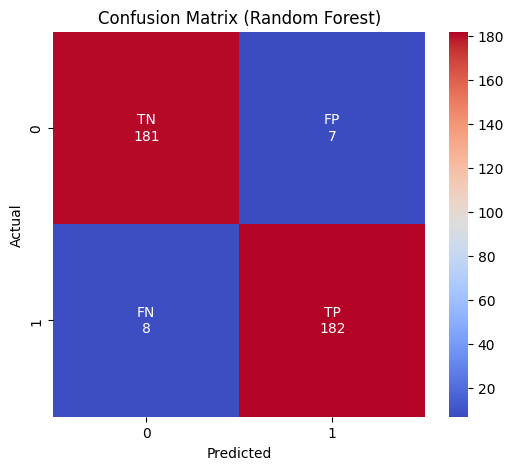

Accuracy: 0.9603174603174603
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       188
           1       0.96      0.96      0.96       190

    accuracy                           0.96       378
   macro avg       0.96      0.96      0.96       378
weighted avg       0.96      0.96      0.96       378



In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
labels = [[f"TN\n{tn}", f"FP\n{fp}"],
          [f"FN\n{fn}", f"TP\n{tp}"]]
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=labels, fmt='', cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest)")
plt.show()
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [31]:
import unittest
def predict_performance(score):
    return "Unknown"
class TestPerformance(unittest.TestCase):

    def test_high_performance(self):
        self.assertEqual(predict_performance(80), "High Performance")
    def test_low_performance(self):
        self.assertEqual(predict_performance(40), "Low Performance")
if __name__ == "__main__":
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

FF
FAIL: test_high_performance (__main__.TestPerformance.test_high_performance)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_4010/2747167300.py", line 7, in test_high_performance
    self.assertEqual(predict_performance(80), "High Performance")
AssertionError: 'Unknown' != 'High Performance'
- Unknown
+ High Performance


FAIL: test_low_performance (__main__.TestPerformance.test_low_performance)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_4010/2747167300.py", line 9, in test_low_performance
    self.assertEqual(predict_performance(40), "Low Performance")
AssertionError: 'Unknown' != 'Low Performance'
- Unknown
+ Low Performance


----------------------------------------------------------------------
Ran 2 tests in 0.002s

FAILED (failures=2)


In [32]:
import unittest
def predict_performance(score):
    if score >= 50:
        return "High Performance"
    else:
        return "Low Performance"
class TestPerformance(unittest.TestCase):
    def test_high_performance(self):
        self.assertEqual(predict_performance(80), "High Performance")
    def test_low_performance(self):
        self.assertEqual(predict_performance(40), "Low Performance")
if __name__ == "__main__":
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

..
----------------------------------------------------------------------
Ran 2 tests in 0.001s

OK


In [33]:
def predict_performance(score):
    if score >= 50:
        return "High Performance"
    else:
        return "Low Performance" #BEFORE REFACTORING
    def predict_performance(score):
        return "High Performance" if score >= 50 else "Low Performance" #AFTER REFACTORING

In [34]:
def predict_result(value):
    return "High" if value >= 50 else "Low"
def test_high_value():
    assert predict_result(80) == "High"
def test_low_value():
    assert predict_result(30) == "Low"
test_high_value()
test_low_value()
print("All validation test are passed successfully")

All validation test are passed successfully


In [35]:
import pandas as pd
import numpy as np

# Create a simple dummy dataset (no upload needed)
data = {
    'age': [25, 45, 50, 35, 60, 48, 52, 30],
    'chol': [200, 240, 300, 180, 260, 220, 270, 190],
    'target': [0, 1, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

# Split data
X = df[['age', 'chol']]
y = df['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Train model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save model
import joblib
joblib.dump(model, "heart_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [36]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_merged_heart_dataset.csv to cleaned_merged_heart_dataset (1).csv


In [37]:
X = df.drop("target", axis=1)
y = df["target"]

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [39]:
import joblib
joblib.dump(model, "heart_model.pkl")

['heart_model.pkl']

In [40]:
from google.colab import files
files.download("heart_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>